In [1]:
import numpy as nn
import matplotlib.pyplot as pp
import pandas as pd
from scipy import integrate, interpolate
from os import getenv

from icecube import dataio, icetray, dataclasses, phys_services, clsim
from icecube import icetray
from I3Tray import I3Tray
from icecube.icetray import I3Units
from segments import PropagateMuons

from Generators import AtmosphericMuons

In [2]:
f2160 = getenv("PONESRCDIR")+"/data/AtmosphericMuons/fluxtable_2160m.csv"
f1460 = getenv("PONESRCDIR")+"/data/AtmosphericMuons/fluxtable_1460m.csv"

# Propagation tests

In [3]:
def closest(particle, target):
    pos = particle.pos
    dir = particle.dir
    x = nn.array([pos.x-target.x, pos.y-target.y, pos.z-target.z])
    v = nn.array([dir.x, dir.y, dir.z])
    lam = -nn.dot(x, v)
    if lam < 0:
        lam = 0
    elif lam > particle.length:
        lam = particle.length
    closest = x + v*lam
    return nn.linalg.norm(closest)

injected_muons = []
injected_flux  = []
def test_injected(frame):
    injected_muons.append(frame["MuonGeneratorI3MCTree"][0])
    injected_flux.append(frame["MuonGeneratorIndividualFlux"].value)
    global injected_area, injected_total_flux
    injected_area = frame["MuonGeneratorArea"].value
    injected_total_flux = frame["MuonGeneratorTotalFlux"].value
    
propagated_muons = []
def test_propagated(frame):
    dcenter = dataclasses.I3Position(0,0,0)
    
    hr = []
    hp = []
    for secondary in frame["muon_track"]:
        if str(secondary.type) == "MuMinus":
            hr.append(closest(secondary, dcenter))
            hp.append(secondary)
    if nn.min(hr) < prop_detector_radius:
        propagated_muons.append(hp[nn.argmin(hr)])
        
injection_radius     = 700*I3Units.m
prop_detector_radius = 100*I3Units.m

In [4]:
%%time
rand = phys_services.I3SPRNGRandomService(seed      = 0, 
                                          nstreams  = 100000000, 
                                          streamnum = 0)

tray = I3Tray()
tray.Add("I3InfiniteSource")
tray.AddModule(AtmosphericMuons.MuonGenerator,
               InjectionHeight=700*I3Units.m,
               InjectionRadius=injection_radius,
               RandomService=rand)
tray.Add(test_injected, Streams=[icetray.I3Frame.DAQ])
tray.Add(PropagateMuons,
        RandomService=rand,
        SaveState=True,
        InputMCTreeName="MuonGeneratorI3MCTree",
        OutputMCTreeName="muon_track",
        PROPOSAL_config_file="../sim/proposal_config.json")
tray.Add(test_propagated, Streams=[icetray.I3Frame.DAQ])
tray.Execute(int(1e5))
tray.Finish()

CPU times: user 1min 29s, sys: 1.81 s, total: 1min 30s
Wall time: 1min 32s


/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/site-packages/numpy/lib/histograms.py:908: RuntimeWarning: divide by zero encountered in true_divide
  return n/db/n.sum(), bin_edges
/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/site-packages/numpy/lib/histograms.py:908: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


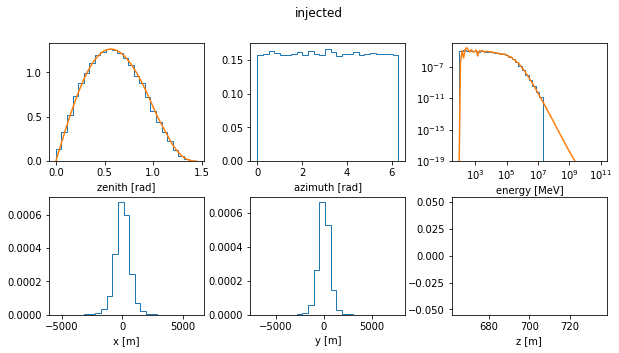

total MUTE flux:      4.3395e-03 /m²s
total simulated flux: 4.3395e-03 /cm²s


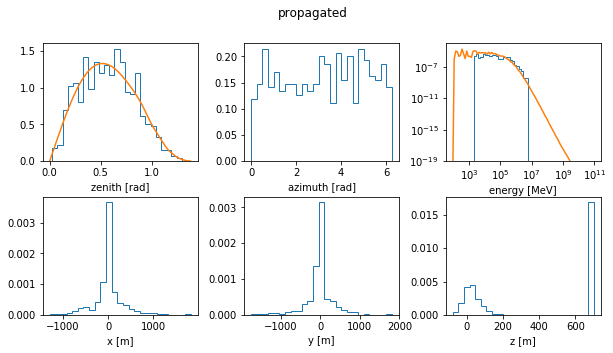

total MUTE flux:      1.1019e-03 /m²s
total simulated flux: 1.1482e-03 /cm²s


In [5]:
def plot(muons, fluxfile, title, radius, weights=None):
    d = pd.read_csv(fluxfile, 
                    comment="#",
                    delim_whitespace=True,
                    header=None,
                    nrows=None)
    flux_angle_rad  = nn.array(d.loc[0,1:],  dtype='float') / 180 * nn.pi
    flux_energy_mev = nn.array(d.loc[1:,0],  dtype='float')
    flux            = nn.array(d.loc[1:,1:], dtype='float')
    flux[flux<0]    = 0

    angle_int     = integrate.simps(flux,      flux_energy_mev, axis=0)
    energy_int    = integrate.simps(flux,      flux_angle_rad,  axis=1)
    total_int     = integrate.simps(angle_int, flux_angle_rad,  axis=0)
    total_flux    = integrate.simps(angle_int*nn.sin(flux_angle_rad)*2*nn.pi, 
                                    flux_angle_rad,  axis=0) / I3Units.s / I3Units.cm2
    
    pp.figure(figsize=(10,5))
    pp.subplots_adjust(wspace=0.3, hspace=0.3)
    pp.suptitle(title)
    pp.subplot(231)
    pp.hist([m.dir.zenith for m in muons], 
            bins=25, histtype="step", density=True, weights=weights)
    y = angle_int*nn.sin(flux_angle_rad)
    pp.plot(flux_angle_rad, 
            y/integrate.simps(y, flux_angle_rad, axis=0),
            label="MUTE input")
    pp.xlabel("zenith [rad]")
    
    pp.subplot(232)
    pp.hist([m.dir.azimuth for m in muons], 
            bins=25, histtype="step", density=True, weights=weights)
    pp.xlabel("azimuth [rad]")
    
    pp.subplot(233)
    e = [m.energy/I3Units.MeV for m in muons]
    pp.hist(e, bins=nn.logspace(nn.log10(min(e)), nn.log10(max(e)), 25),
            histtype="step", density=True, weights=weights)
    pp.plot(flux_energy_mev, energy_int/total_int,
            label="MUTE input")
    pp.xlabel("energy [MeV]")
    pp.xscale("log")
    pp.yscale("log")
    pp.ylim(1e-19, 1e-4)
    
    pp.subplot(234)
    pp.hist([m.pos.x for m in muons], 
            bins=25, histtype="step", density=True, weights=weights)
    pp.xlabel("x [m]")
    
    pp.subplot(235)
    pp.hist([m.pos.y for m in muons], 
            bins=25, histtype="step", density=True, weights=weights)
    pp.xlabel("y [m]")
    
    pp.subplot(236)
    pp.hist([m.pos.z for m in muons], 
            bins=25, histtype="step", density=True, weights=weights)
    pp.xlabel("z [m]")
    pp.show()
    
    print("total MUTE flux:      %.4e /m²s" % (total_flux*I3Units.s*I3Units.m2))
    muons_per_second = injected_total_flux * injected_area * I3Units.s
    total_time = len(injected_muons)/muons_per_second
    simflux  = len(muons)/total_time/(nn.pi*radius**2)
    print("total simulated flux: %.4e /cm²s" % simflux)

plot(injected_muons,   f1460,
     "injected",       injection_radius)
plot(propagated_muons, f2160,
     "propagated",     prop_detector_radius)

# Reweighting tests

In [6]:
def f(frame):
    injected_muons.append(frame["MuonGeneratorI3MCTree"][0])
    injected_weight.append(frame["MuonReweighterWeight"].value)

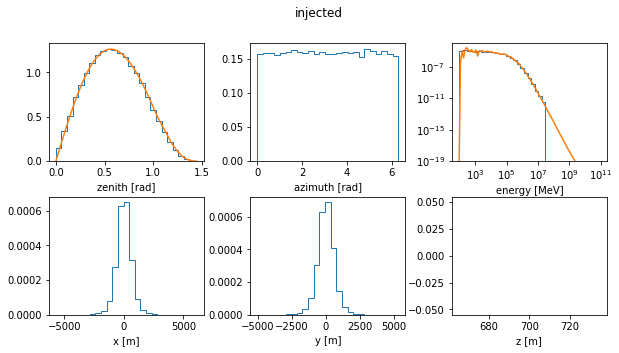

total MUTE flux:      4.3395e-03 /m²s
total simulated flux: 4.3395e-03 /cm²s


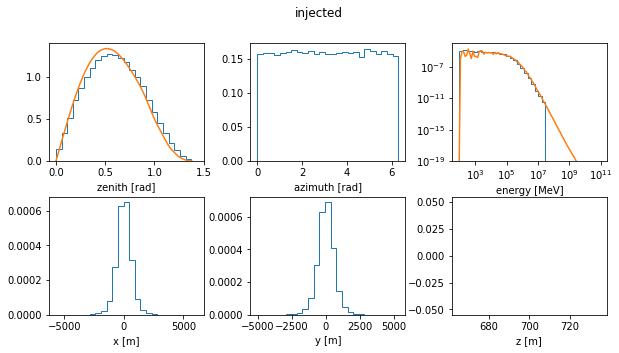

total MUTE flux:      1.1019e-03 /m²s
total simulated flux: 4.3395e-03 /cm²s


In [7]:
injected_muons  = []
injected_weight = []
tray = I3Tray()
tray.Add("I3InfiniteSource")
tray.AddModule(AtmosphericMuons.MuonGenerator,
    InjectionHeight=700,
    InjectionRadius=injection_radius,
    RandomService=rand)
tray.Add(AtmosphericMuons.MuonReweighter)
tray.Add(f, Streams=[icetray.I3Frame.DAQ])
tray.Execute(int(1e5))
tray.Finish()

injected_muons  = nn.array(injected_muons)
injected_weight = nn.array(injected_weight)
select = nn.logical_not(nn.isnan(injected_weight))

plot(injected_muons[select],   f1460,
     "injected",       injection_radius, weights=injected_weight[select])
plot(injected_muons[select],   f2160,
     "injected",       injection_radius, weights=injected_weight[select])

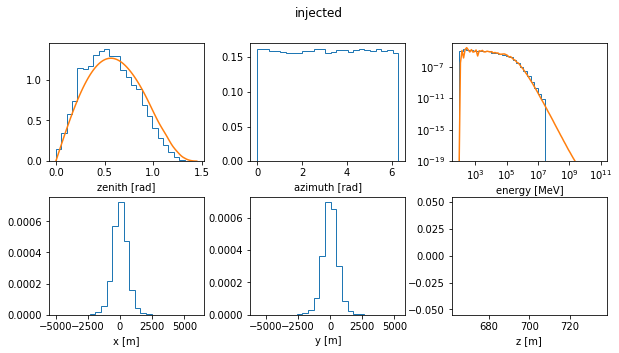

total MUTE flux:      4.3395e-03 /m²s
total simulated flux: 4.3386e-03 /cm²s


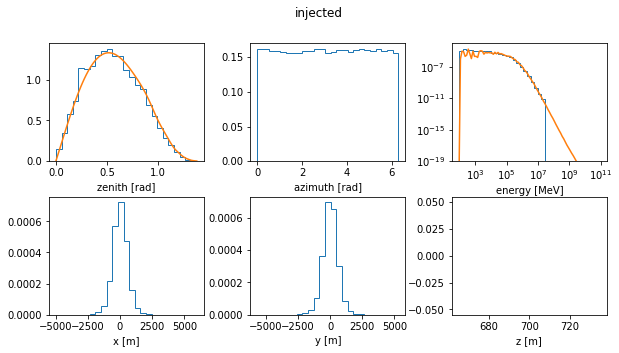

total MUTE flux:      1.1019e-03 /m²s
total simulated flux: 4.3386e-03 /cm²s


In [8]:
injected_muons  = []
injected_weight = []
tray = I3Tray()
tray.Add("I3InfiniteSource")
tray.AddModule(AtmosphericMuons.MuonGenerator,
    InjectionHeight=700,
    InjectionRadius=injection_radius,
    RandomService=rand)
tray.Add(AtmosphericMuons.MuonReweighter,
    Fluxfile=getenv("PONESRCDIR")+"/data/AtmosphericMuons/fluxtable_2160m.csv")
tray.Add(f, Streams=[icetray.I3Frame.DAQ])
tray.Execute(int(1e5))
tray.Finish()

injected_muons  = nn.array(injected_muons)
injected_weight = nn.array(injected_weight)
select = nn.logical_not(nn.isnan(injected_weight))

plot(injected_muons[select],   f1460,
     "injected",       injection_radius, weights=injected_weight[select])
plot(injected_muons[select],   f2160,
     "injected",       injection_radius, weights=injected_weight[select])